#  Visualisation & Exploration

**Projet BI 25/26 — Groupe 7**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
pd.set_option('display.max_columns', 50)

customers    = pd.read_csv('dataset/cleaned/customers_clean.csv', parse_dates=['purchase_date'])
traffic      = pd.read_csv('dataset/cleaned/traffic_clean.csv',   parse_dates=['date'])
df_churn     = pd.read_csv('dataset/cleaned/df_churn.csv')
df_purchased = pd.read_csv('dataset/cleaned/df_purchased.csv')
churn_labels = pd.read_csv('dataset/cleaned/churn_labels.csv')

print('Données chargées :')
print(f'  customers    : {customers.shape}')
print(f'  traffic      : {traffic.shape}')
print(f'  df_churn     : {df_churn.shape}')
print(f'  df_purchased : {df_purchased.shape}')

Données chargées :
  customers    : (250000, 12)
  traffic      : (215913, 10)
  df_churn     : (49661, 22)
  df_purchased : (215913, 16)


## Distribution des cibles

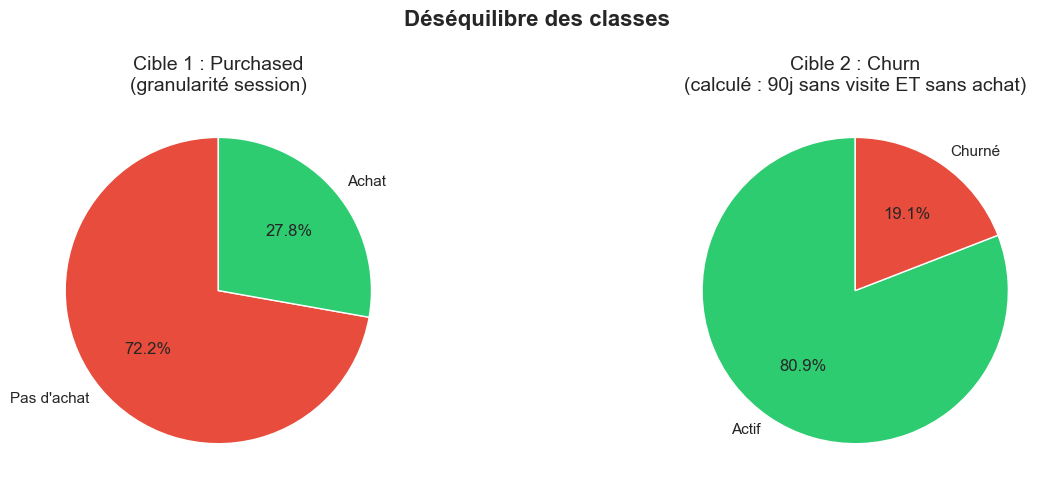

Taux d'achat  : 27.8%
Taux de churn : 19.1%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cible 1 : Purchased
purchased_counts = df_purchased['purchased'].value_counts()
axes[0].pie(purchased_counts, labels=["Pas d'achat", 'Achat'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Cible 1 : Purchased\n(granularité session)')

# Cible 2 : Churn (calculé depuis les activités)
churn_counts = df_churn['churn'].value_counts()
axes[1].pie(churn_counts, labels=['Actif', 'Churné'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Cible 2 : Churn\n(calculé : 90j sans visite ET sans achat)')

plt.suptitle('Déséquilibre des classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Taux d'achat  : {df_purchased['purchased'].mean():.1%}")
print(f"Taux de churn : {df_churn['churn'].mean():.1%}")

## Jours d'inactivité des clients churné vs actifs

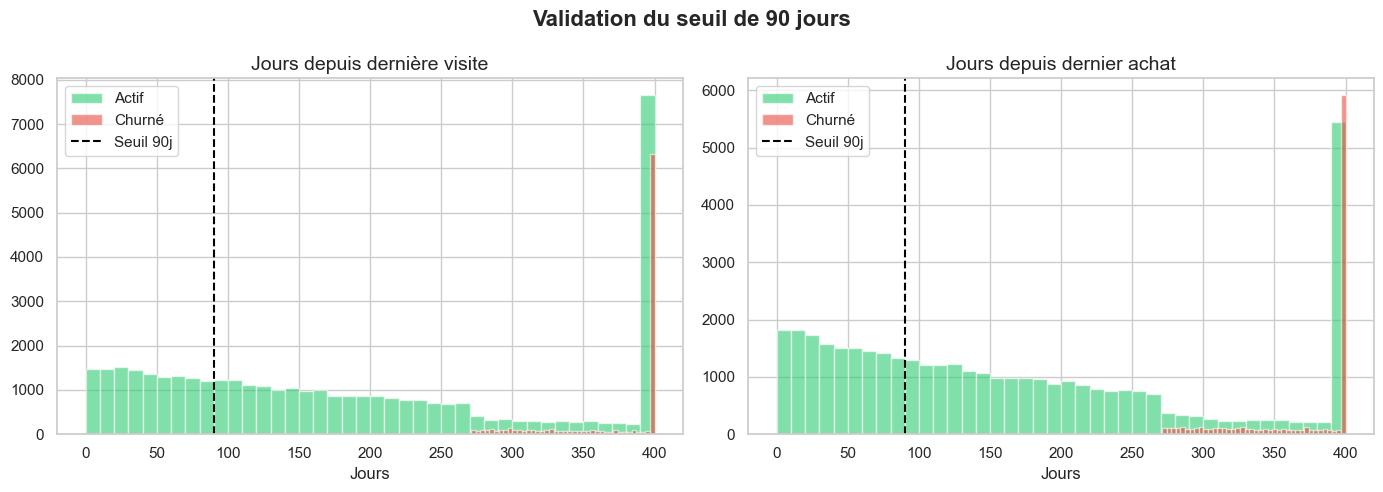

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jours depuis visite
for label, color, group in [(0, '#2ecc71', 'Actif'), (1, '#e74c3c', 'Churné')]:
    subset = df_churn[df_churn['churn'] == label]['jours_depuis_visite'].clip(upper=400)
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=group)
axes[0].axvline(90, color='black', linestyle='--', linewidth=1.5, label='Seuil 90j')
axes[0].set_title('Jours depuis dernière visite')
axes[0].set_xlabel('Jours')
axes[0].legend()

# Jours depuis achat
for label, color, group in [(0, '#2ecc71', 'Actif'), (1, '#e74c3c', 'Churné')]:
    subset = df_churn[df_churn['churn'] == label]['jours_depuis_achat'].clip(upper=400)
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=group)
axes[1].axvline(90, color='black', linestyle='--', linewidth=1.5, label='Seuil 90j')
axes[1].set_title('Jours depuis dernier achat')
axes[1].set_xlabel('Jours')
axes[1].legend()

plt.suptitle('Validation du seuil de 90 jours', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Comportement des clients churné vs actifs

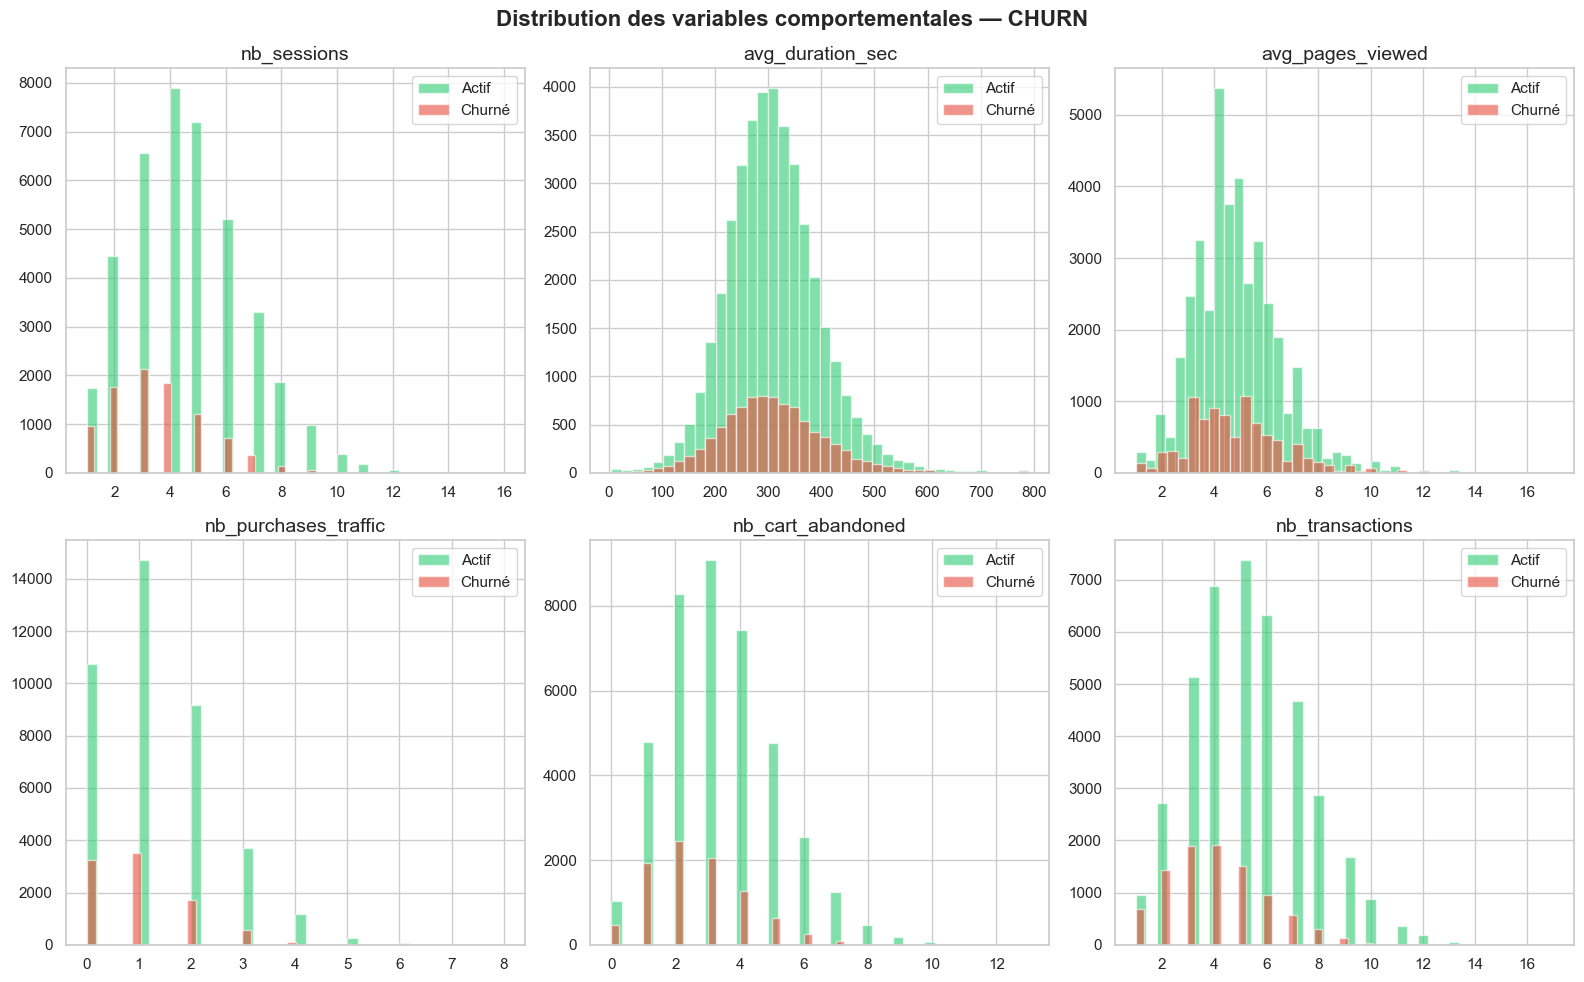

In [4]:
num_cols = ['nb_sessions', 'avg_duration_sec', 'avg_pages_viewed',
            'nb_purchases_traffic', 'nb_cart_abandoned', 'nb_transactions']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col not in df_churn.columns:
        continue
    axes[i].hist(df_churn[df_churn['churn']==0][col].dropna(), bins=40, alpha=0.6, color='#2ecc71', label='Actif')
    axes[i].hist(df_churn[df_churn['churn']==1][col].dropna(), bins=40, alpha=0.6, color='#e74c3c', label='Churné')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Distribution des variables comportementales — CHURN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Variables catégorielles

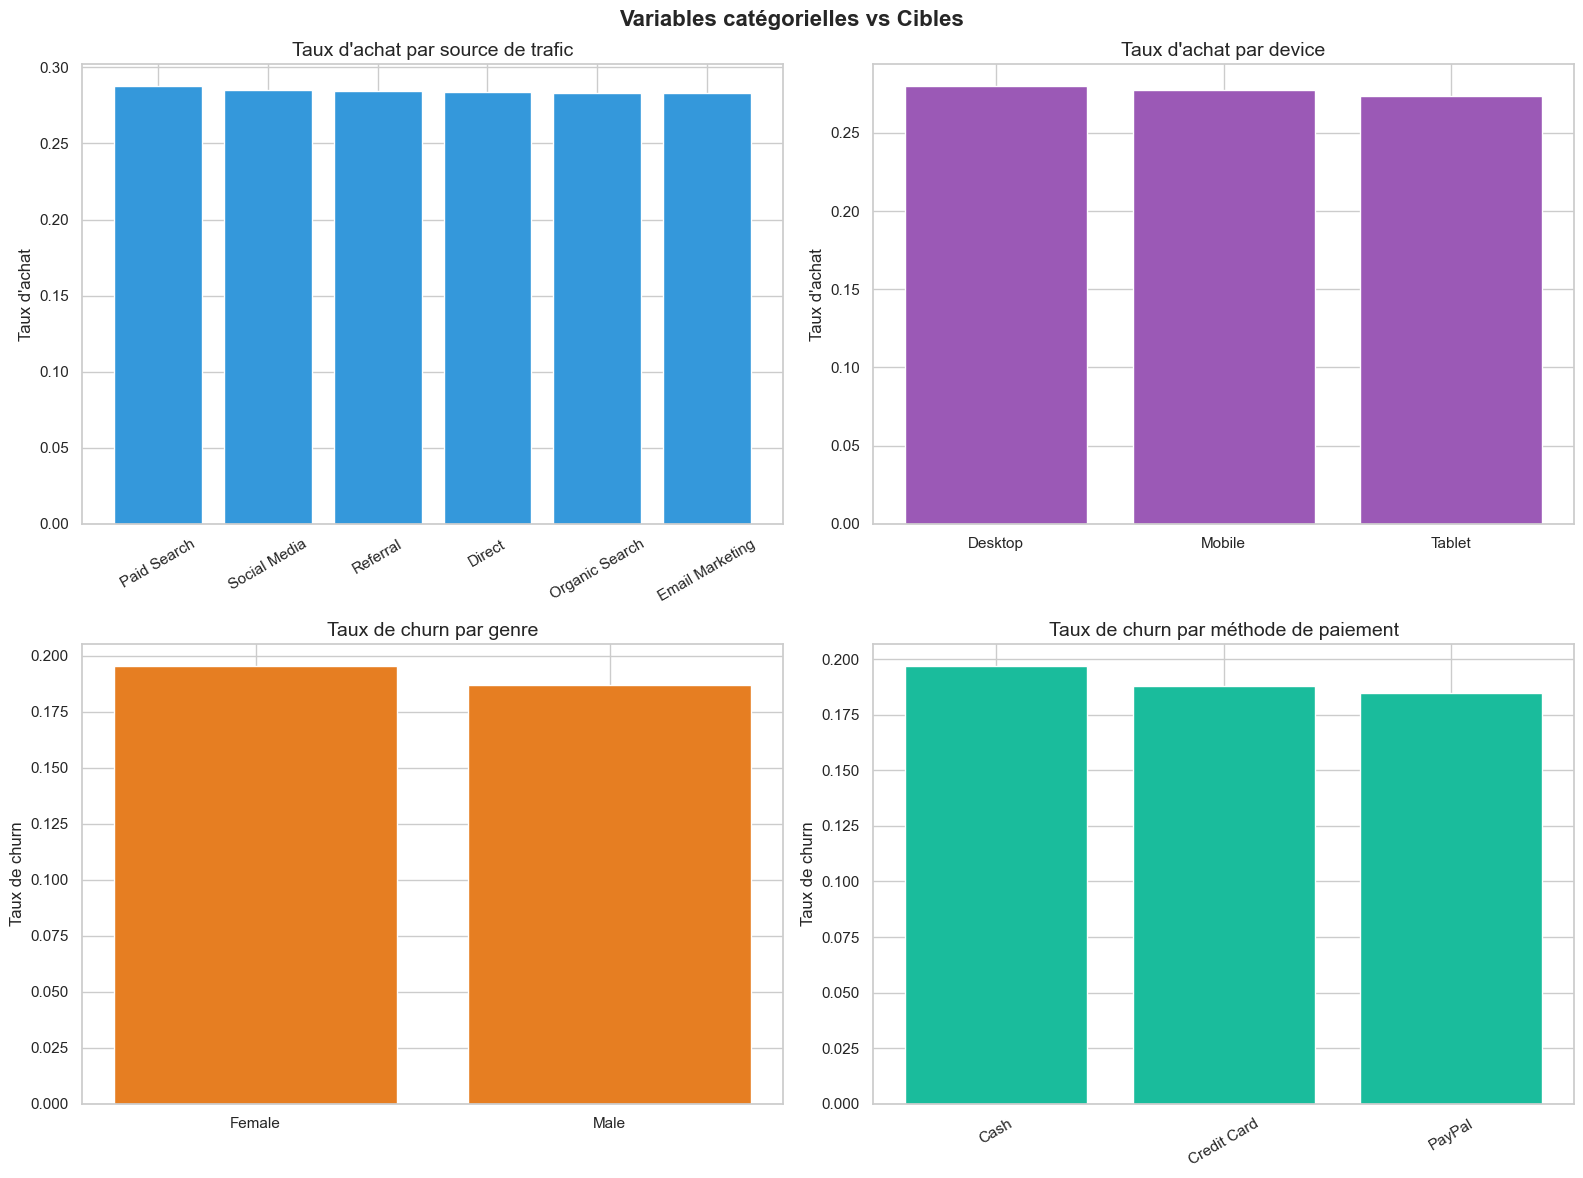

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Source trafic vs Purchased
ts = df_purchased.groupby('traffic_source')['purchased'].mean().sort_values(ascending=False)
axes[0, 0].bar(ts.index, ts.values, color='#3498db')
axes[0, 0].set_title("Taux d'achat par source de trafic")
axes[0, 0].set_ylabel("Taux d'achat")
axes[0, 0].tick_params(axis='x', rotation=30)

# Device vs Purchased
dv = df_purchased.groupby('device')['purchased'].mean().sort_values(ascending=False)
axes[0, 1].bar(dv.index, dv.values, color='#9b59b6')
axes[0, 1].set_title("Taux d'achat par device")
axes[0, 1].set_ylabel("Taux d'achat")

# Genre vs Churn
gv = df_churn.groupby('gender')['churn'].mean().sort_values(ascending=False)
axes[1, 0].bar(gv.index, gv.values, color='#e67e22')
axes[1, 0].set_title('Taux de churn par genre')
axes[1, 0].set_ylabel('Taux de churn')

# Méthode paiement vs Churn
pm = df_churn.groupby('payment_method')['churn'].mean().sort_values(ascending=False)
axes[1, 1].bar(pm.index, pm.values, color='#1abc9c')
axes[1, 1].set_title('Taux de churn par méthode de paiement')
axes[1, 1].set_ylabel('Taux de churn')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Variables catégorielles vs Cibles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Heatmap des corrélations

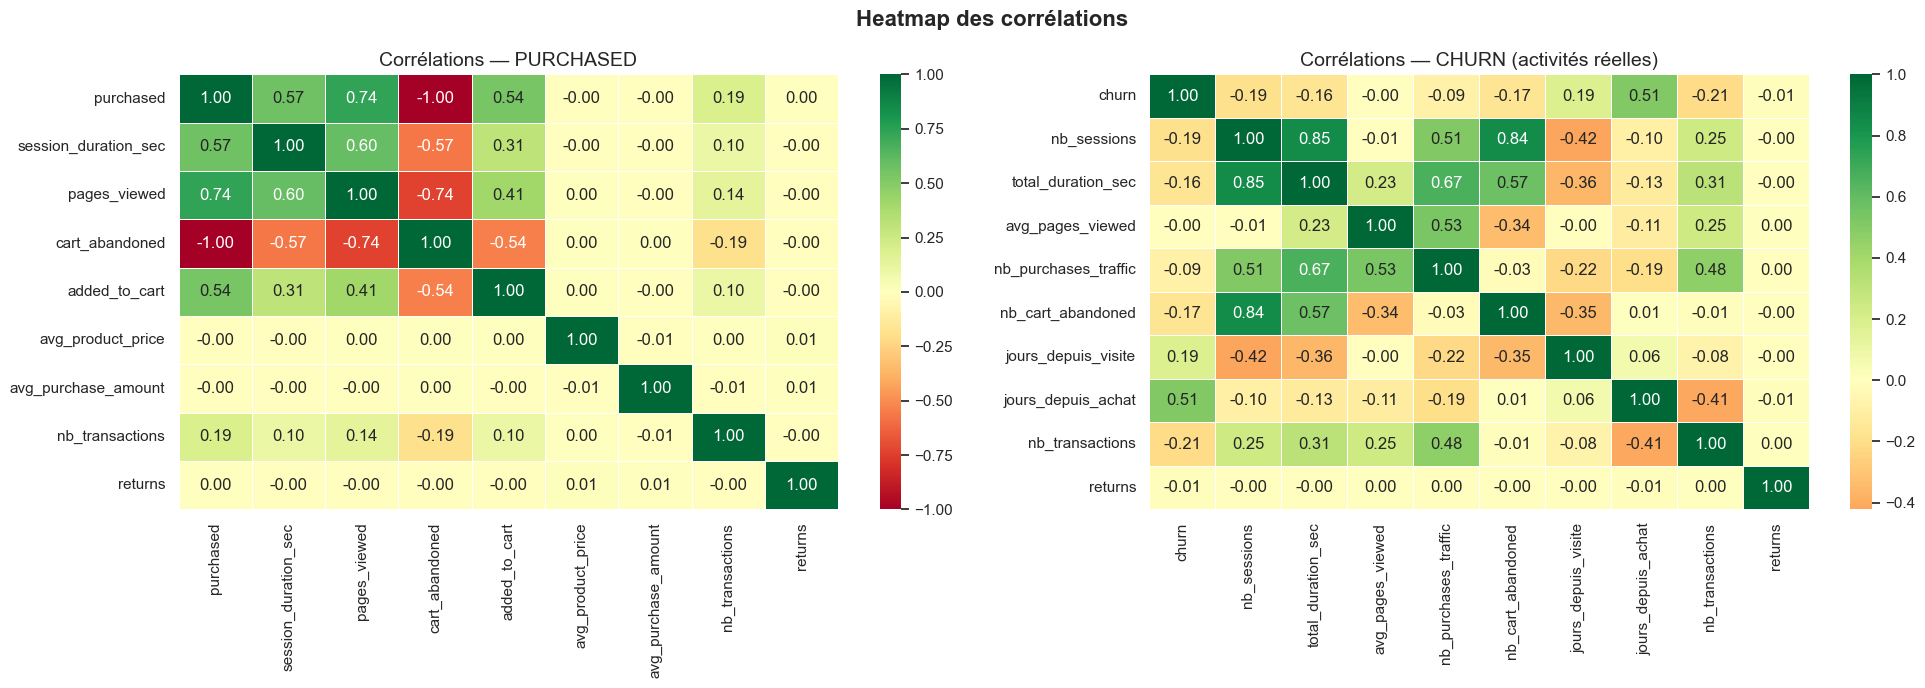

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# PURCHASED
cols_p = ['purchased', 'session_duration_sec', 'pages_viewed',
          'cart_abandoned', 'added_to_cart', 'avg_product_price',
          'avg_purchase_amount', 'nb_transactions', 'returns']
cols_p = [c for c in cols_p if c in df_purchased.columns]
corr_p = df_purchased[cols_p].corr()
sns.heatmap(corr_p, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Corrélations — PURCHASED', fontsize=14)

# CHURN (variables comportementales calculées)
cols_c = ['churn', 'nb_sessions', 'total_duration_sec', 'avg_pages_viewed',
          'nb_purchases_traffic', 'nb_cart_abandoned', 'jours_depuis_visite',
          'jours_depuis_achat', 'nb_transactions', 'returns']
cols_c = [c for c in cols_c if c in df_churn.columns]
corr_c = df_churn[cols_c].corr()
sns.heatmap(corr_c, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Corrélations — CHURN (activités réelles)', fontsize=14)

plt.suptitle('Heatmap des corrélations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()